In [77]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [78]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from dataclasses import dataclass

# On importe les classes de physique uniquement
# Assurez-vous que dans code_bempp.py, il n'y a plus "import bempp.api"
from code_extraction import Extraction, Paraxial, Ion, Trajectoire, abberation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


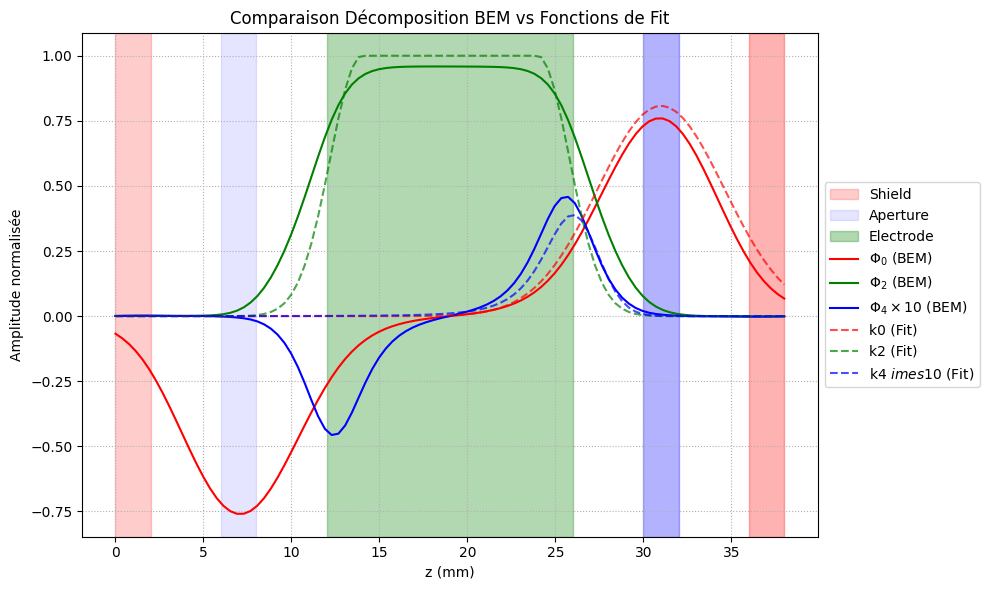

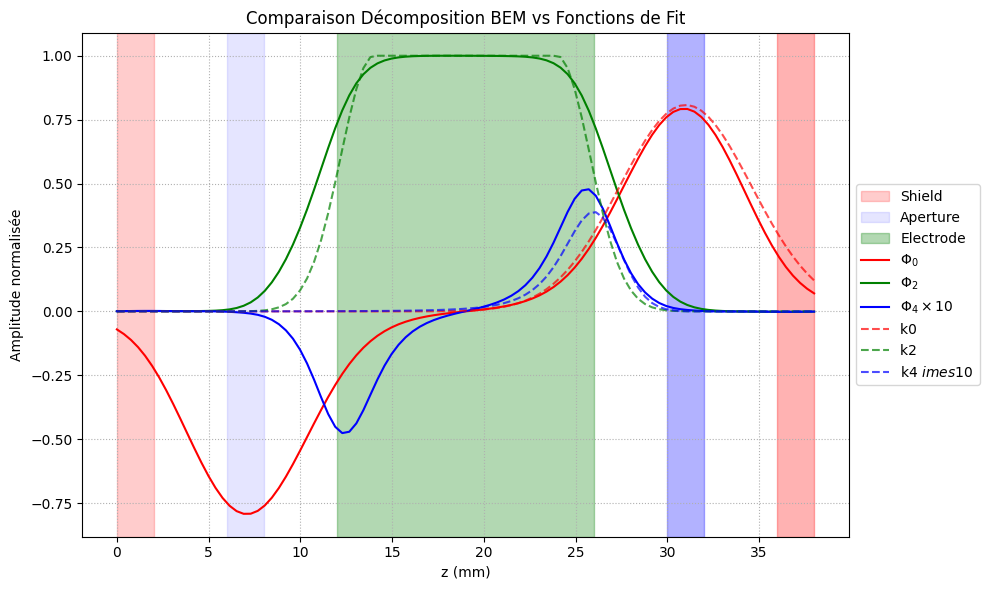

In [79]:

# 1. Définition du chemin du fichier sauvegardé
file_path =r"potentiel_quadrupole_VF.npz"

#importatation du ficher 
data = Extraction(file_path)

# 3. Calcul de la décomposition multipolaire (Phi0, Phi2, Phi4)
data.derive()
data.decompose()
data.fit_functions()
data.normalisation()
data.plot_decomposition()
data.plot_normalisation()


20000.0
20000.0


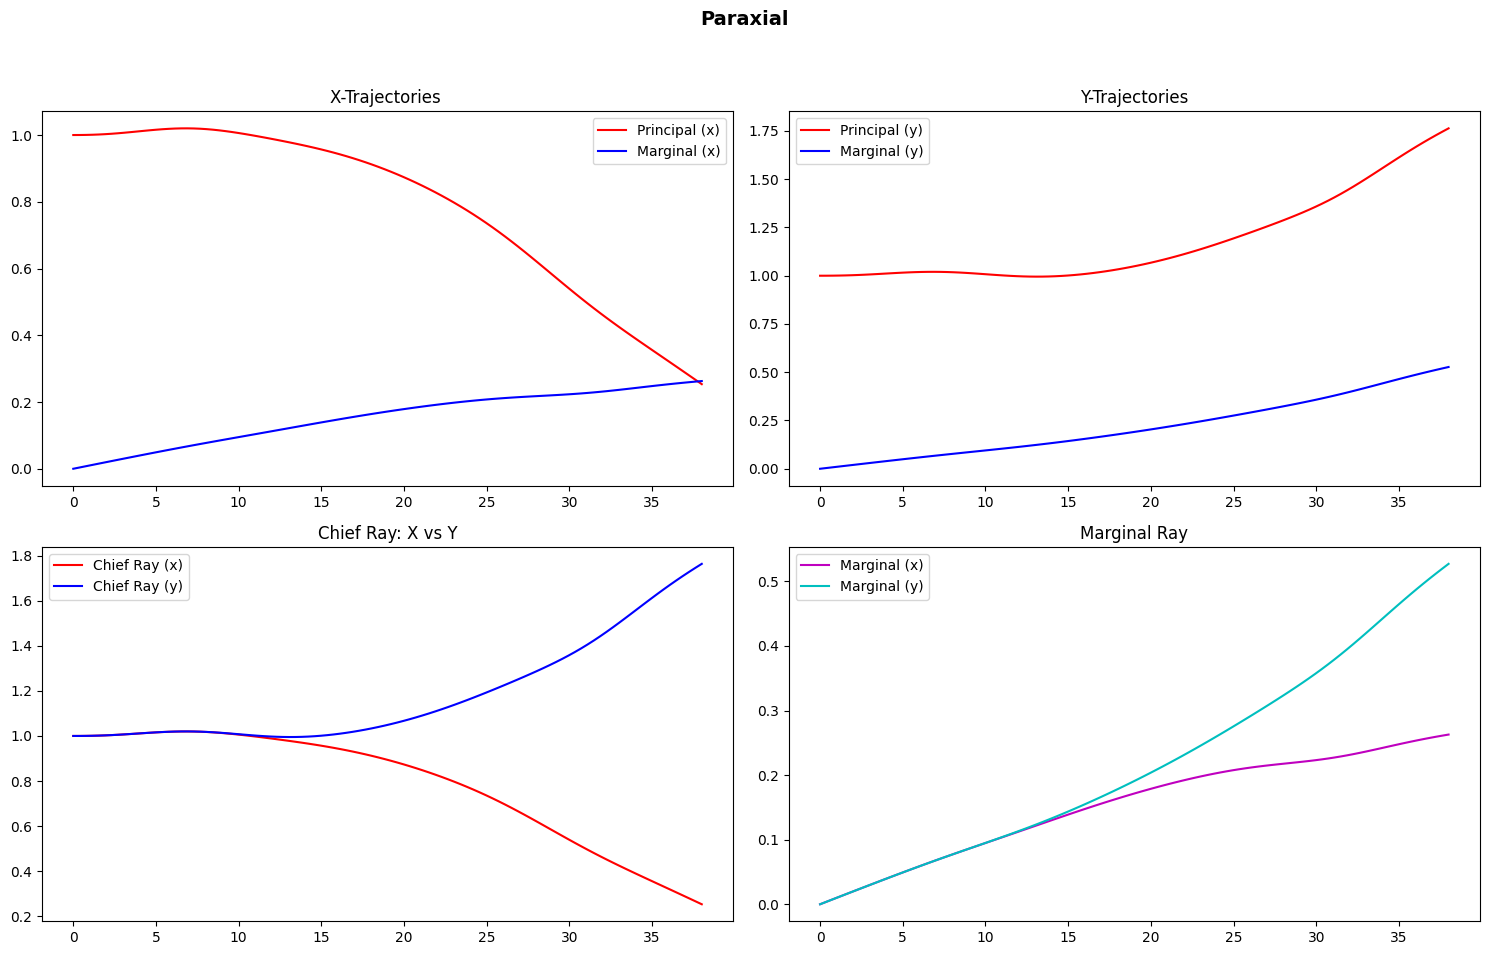

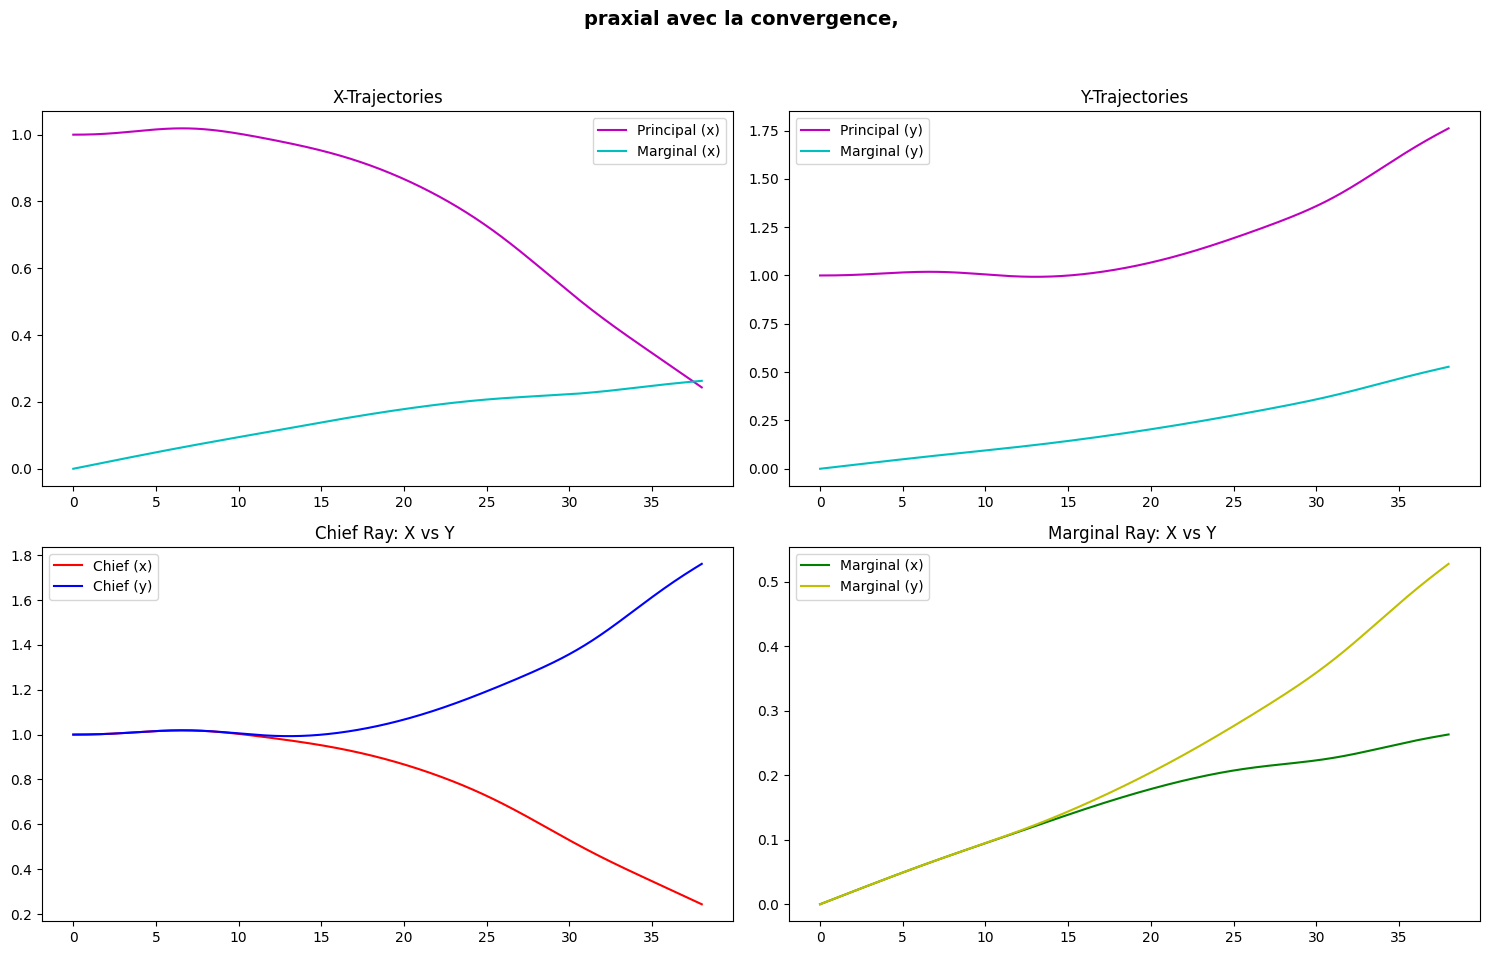

In [80]:
e = -1.6e-19
# 1. Initialisation
mon_moteur = Trajectoire()
convergence = Trajectoire()

# 2. Simulation Discrète

marginal = Ion(1.6e-27, e, "principal", 0, 0.01, 0, 0.01)
principal = Ion(1.6e-27, e, "marginal", 1, 0, 1, 0)
mon_moteur.simulation3(marginal, data)
mon_moteur.simulation3(principal, data)
mon_moteur.plot_discret(principal, marginal, data)

# 3. Simulation Continue
# n -> à choisir pour l'odre de la convergence(reduit le pas)
marginalc = Ion(1.6e-27, e, "p_cont", 0, 0.01, 0, 0.01)
principalc = Ion(1.6e-27, e, "p_cont", 1, 0, 1, 0)
convergence.convergence(data, n=5) 
convergence.simulationf(marginalc, data)
convergence.simulationf(principalc, data)
convergence.plot_continu(principalc, marginalc, data)

Abberation 

pour voir si ya de l'abbération spérique 


20000.0
20000.0
20000.0
20000.0
20000.0
20000.0
20000.0
20000.0
20000.0
20000.0


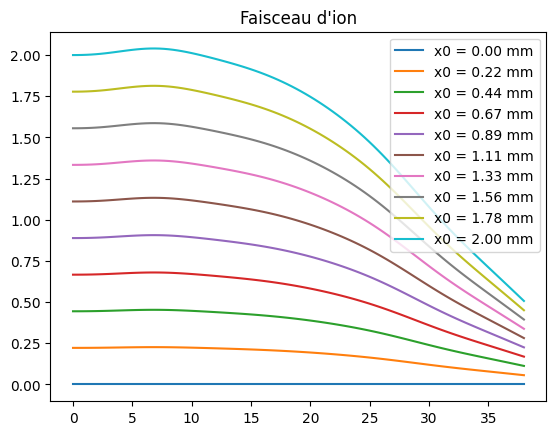

In [81]:
e = -1.6e-19
# 1. Initialisation
mon_moteur = Trajectoire()
convergence = Trajectoire()
liste = []

#n nombre d'ion que l'on veut 
n = 10

positions_initiales = np.linspace(0, 2.0, n)
for i in positions_initiales:
    ion= Ion(1.6e-27, e, f"Ion_{i:.1f}", i, 0.00, i, 0.00)
    mon_moteur.simulation3(ion, data)
    liste.append(ion)

mon_moteur.plot_faisceau(liste,  data)

In [82]:
Xcoef = abberation()
x =Xcoef.coefficient(marginal, data)

7.475134331614235e-08
